# Assignment 4
### Swish

In [1]:
import torch
torch.cuda.is_available()

False

In [2]:
x = torch.tensor([2.0], requires_grad=True)
print(x)

tensor([2.], requires_grad=True)


In [3]:
y = x ** 2 + 2 * x + 1
print(y)

tensor([9.], grad_fn=<AddBackward0>)


In [4]:
y.backward()

In [5]:
x.grad

tensor([6.])

In [ ]:
import torch

x = torch.tensor([1., 2., 3.], requires_grad=True)
y = x.sum()
y.backward()
print(x.grad)

tensor([1., 1., 1.])


### Exercise 1 

Compute the gradient for the sigmoid activation function in 2 points using pytorch and check it with the known explicit formula 

Sigmoid activation function : $$f(x) = \frac{1}{1+e^{-x}}.$$


In [ ]:
x = torch.tensor([0., 2.], requires_grad=True)

sigmoid = torch.nn.Sigmoid()
y = sigmoid(x)
# print(y)

y.sum().backward()
print(x.grad)

tensor([0.2500, 0.1050])


In [22]:
x = torch.tensor([0., 2.], requires_grad=True)
sigmoid = torch.nn.Sigmoid()
y = sigmoid(x)
manual = y * (1 - y)

print(manual)

tensor([0.2500, 0.1050], grad_fn=<MulBackward0>)


### Exercise 2

Compute the gradient for the linear activation function in 2 points using pytorch and check it with the known explicit formula

linear activation function: $$f(x) = x.$$

In [23]:
x = torch.tensor([0., 2.], requires_grad=True)

y = x
y.sum().backward()

print(x.grad)

tensor([1., 1.])


In [24]:
print(torch.ones_like(x))

tensor([1., 1.])


### Exersise 3

Compute the gradient for the relu activation function in 2 points using pytorch and check it with the known explicit formula.

relu activation function: $$f(x) = max(0, x)$$

In [27]:
x = torch.tensor([1., -2.], requires_grad=True)

r = torch.nn.ReLU()
y = r(x)
y.sum().backward()

print(x.grad)

tensor([1., 0.])


In [29]:
x = torch.tensor([1., -2.])

manual = (x > 0).float()
print(manual)

tensor([1., 0.])


### Exersise 4

Write in python a function to plot the sigmoid activation function and its gradient using matplotlib.

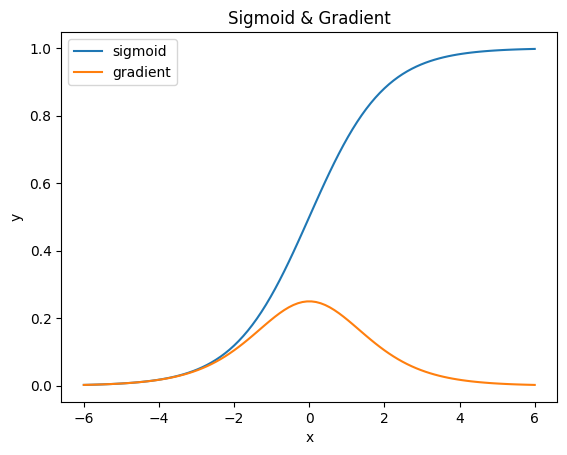

In [41]:
import matplotlib.pyplot as plt

def plot_sigmoid():
    x = torch.linspace(-6, 6, 100, requires_grad=True)

    s = torch.nn.Sigmoid()
    y = s(x)
    y.sum().backward()
    
    plt.plot(x.detach(), y.detach(), label='sigmoid')
    plt.plot(x.detach(), x.grad.detach(), label='gradient')

    plt.legend()
    plt.title('Sigmoid & Gradient')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_sigmoid()

### Exersise 5

Write in python a function to plot the ReLU activation function and its gradient using matplotlib.

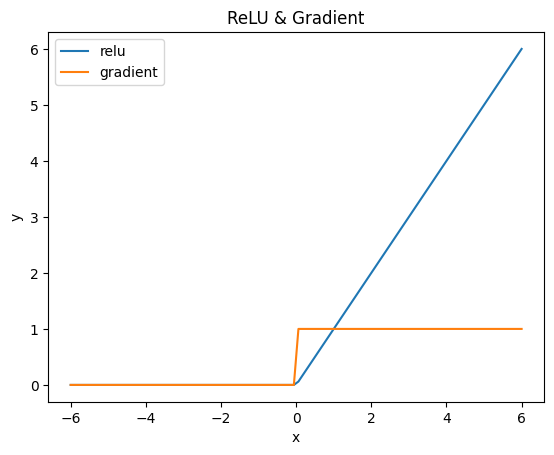

In [42]:
import matplotlib.pyplot as plt

def plot_relu():
    x = torch.linspace(-6, 6, 100, requires_grad=True)

    r = torch.nn.ReLU()
    y = r(x)
    y.sum().backward()
    
    plt.plot(x.detach(), y.detach(), label='relu')
    plt.plot(x.detach(), x.grad.detach(), label='gradient')

    plt.legend()
    plt.title('ReLU & Gradient')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_relu()

# Exercise 6
Write in python a function to plot the tanh activation function and its gradient using matplotlib.

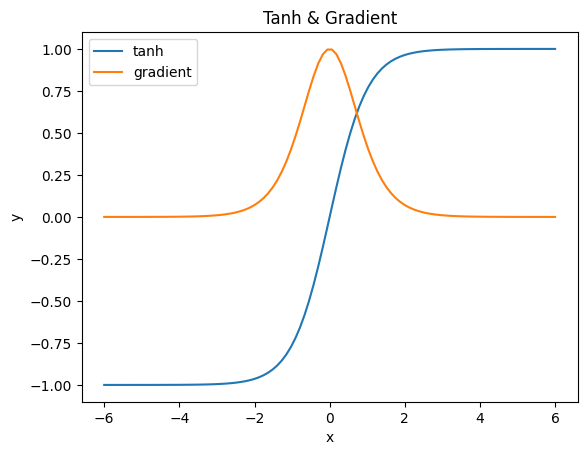

In [45]:
import matplotlib.pyplot as plt

def plot_tanh():
    x = torch.linspace(-6, 6, 100, requires_grad=True)

    r = torch.nn.Tanh()
    y = r(x)
    y.sum().backward()
    
    plt.plot(x.detach(), y.detach(), label='tanh')
    plt.plot(x.detach(), x.grad.detach(), label='gradient')

    plt.legend()
    plt.title('Tanh & Gradient')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_tanh()

### Exercise 7
Write in python a function to plot the leaky ReLU activation function and its gradient using matplotlib.

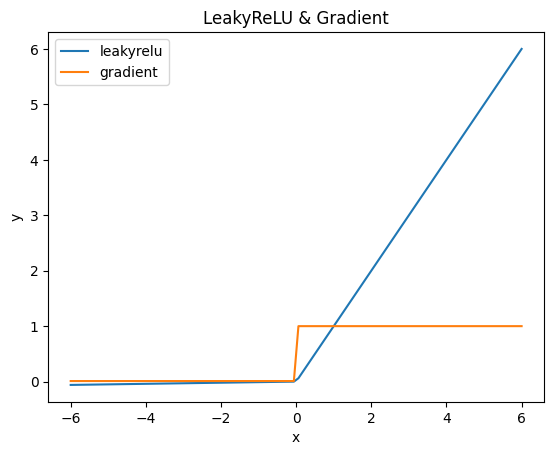

In [46]:
import matplotlib.pyplot as plt

def plot_leaky_relu():
    x = torch.linspace(-6, 6, 100, requires_grad=True)

    r = torch.nn.LeakyReLU()
    y = r(x)
    y.sum().backward()
    
    plt.plot(x.detach(), y.detach(), label='leakyrelu')
    plt.plot(x.detach(), x.grad.detach(), label='gradient')

    plt.legend()
    plt.title('LeakyReLU & Gradient')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

plot_leaky_relu()

# Perceptron

In [47]:
import torch
import torch.nn as nn

input_size = 2
output_size = 1

class Perceptron(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Perceptron, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
        self.activation = torch.nn.Sigmoid()
        
    def forward(self, x):
        x = self.linear(x)
        x = self.activation(x)
        return x


In [48]:
perceptron = Perceptron(input_size, output_size)
x = torch.tensor([0.5, 0.2])
y = perceptron(x)
print(y)


tensor([0.3999], grad_fn=<SigmoidBackward0>)


In [49]:

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary cross-entropy loss
optimizer = torch.optim.SGD(perceptron.parameters(), lr=0.1)  # Stochastic gradient descent optimizer

# Generate some random input data and labels
input_data = torch.randn((10, input_size))
labels = torch.randint(0, 2, (10, output_size)).float()

# Train the model
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = perceptron(input_data)
    loss = criterion(outputs, labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print the loss every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.6276
Epoch [200/1000], Loss: 0.6217
Epoch [300/1000], Loss: 0.6210
Epoch [400/1000], Loss: 0.6209
Epoch [500/1000], Loss: 0.6209
Epoch [600/1000], Loss: 0.6209
Epoch [700/1000], Loss: 0.6209
Epoch [800/1000], Loss: 0.6209
Epoch [900/1000], Loss: 0.6209
Epoch [1000/1000], Loss: 0.6209


### Exercise 8
Implement a binary classification model using the Perceptron class in PyTorch for the logic OR. 

Your task is to create a Perceptron instance and train it using a proper  dataset and the binary cross-entropy loss with stochastic gradient descent optimizer. 

Here are the steps you can follow:

Define a Perceptron class that inherits from torch.nn.Module and implements a binary classification model.

Define a binary cross-entropy loss function using the torch.nn.BCEWithLogitsLoss module.

Define a stochastic gradient descent optimizer using the torch.optim.SGD module.

Train the Perceptron model on the training set using the binary cross-entropy loss and stochastic gradient descent optimizer.

Evaluate the trained model compute the accuracy.

In [55]:
import torch
import torch.nn as nn

class Perceptron(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Perceptron, self).__init__()
        self.linear = torch.nn.Linear(input_dim, output_dim)
        self.activation = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        x = self.activation(x)
        return x

X = torch.tensor([[0., 0.],
                  [0., 1.],
                  [1., 0.],
                  [1., 1.]])

y = torch.tensor([[0.],
                  [1.],
                  [1.],
                  [1.]])

p = Perceptron(2, 1)

criterion = nn.BCELoss()
optimizer = torch.optim.SGD(p.parameters(), lr=0.1)

for epoch in range(1000):
    optimizer.zero_grad()
    output = p(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

with torch.no_grad():
    predictions = p(X)
    print("\nPredictions:")
    print(predictions.round()) 

Epoch 0, Loss: 0.6762
Epoch 10, Loss: 0.5415
Epoch 20, Loss: 0.4720
Epoch 30, Loss: 0.4315
Epoch 40, Loss: 0.4047
Epoch 50, Loss: 0.3852
Epoch 60, Loss: 0.3697
Epoch 70, Loss: 0.3567
Epoch 80, Loss: 0.3453
Epoch 90, Loss: 0.3350
Epoch 100, Loss: 0.3256
Epoch 110, Loss: 0.3168
Epoch 120, Loss: 0.3085
Epoch 130, Loss: 0.3007
Epoch 140, Loss: 0.2932
Epoch 150, Loss: 0.2862
Epoch 160, Loss: 0.2794
Epoch 170, Loss: 0.2730
Epoch 180, Loss: 0.2668
Epoch 190, Loss: 0.2609
Epoch 200, Loss: 0.2552
Epoch 210, Loss: 0.2497
Epoch 220, Loss: 0.2445
Epoch 230, Loss: 0.2394
Epoch 240, Loss: 0.2346
Epoch 250, Loss: 0.2299
Epoch 260, Loss: 0.2254
Epoch 270, Loss: 0.2210
Epoch 280, Loss: 0.2169
Epoch 290, Loss: 0.2128
Epoch 300, Loss: 0.2089
Epoch 310, Loss: 0.2051
Epoch 320, Loss: 0.2015
Epoch 330, Loss: 0.1980
Epoch 340, Loss: 0.1945
Epoch 350, Loss: 0.1912
Epoch 360, Loss: 0.1880
Epoch 370, Loss: 0.1849
Epoch 380, Loss: 0.1819
Epoch 390, Loss: 0.1790
Epoch 400, Loss: 0.1762
Epoch 410, Loss: 0.1734
Epo